# PSD-разделение двух типов сигналов по отношению площадей

Цель — разделить импульсы на два класса по форме хвоста. Используется метод Pulse Shape Discrimination (PSD): отношение площади хвоста импульса к его полной площади.

Для органических сцинтилляторов быстрый класс обычно связывают с гамма-квантами и электронными отдачами, а медленный класс — с нейтронами и протонными отдачами. В этом наборе нет эталонных меток, поэтому физическое сопоставление остаётся предварительным, а непосредственно из данных надёжно следуют только два класса формы: быстрый и медленный.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.mixture import GaussianMixture

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (13, 6), "font.size": 12})

DATA_PATH = Path("DataR_CH1_run136_6.csv")
OUTPUT_DIR = Path("signal_analysis")
OUTPUT_DIR.mkdir(exist_ok=True)

BASELINE_BINS = 80
TOTAL_START_OFFSET = -5
TOTAL_END_OFFSET = 250
TAIL_START_OFFSET = 10
SATURATION_AMPLITUDE = 14000
RANDOM_STATE = 42

## 1. Загрузка данных

В файле первые шесть полей содержат метаданные, а следующие 496 значений — временную форму импульса. Поля `ENERGY` и `ENERGYSHORT` во всех строках равны нулю, поэтому интегралы рассчитываются непосредственно по форме сигнала.

In [2]:
data = pd.read_csv(DATA_PATH, sep=";", header=None, skiprows=1)
metadata = data.iloc[:, :6].copy()
metadata.columns = ["BOARD", "CHANNEL", "TIMETAG", "ENERGY", "ENERGYSHORT", "FLAGS"]
waveforms = data.iloc[:, 6:].to_numpy(dtype=float)

print(f"Сигналов: {len(waveforms)}")
print(f"Отсчётов в сигнале: {waveforms.shape[1]}")
print(f"Ненулевых ENERGY: {(metadata['ENERGY'] != 0).sum()}")
print(f"Ненулевых ENERGYSHORT: {(metadata['ENERGYSHORT'] != 0).sum()}")

Сигналов: 2000
Отсчётов в сигнале: 496
Ненулевых ENERGY: 0
Ненулевых ENERGYSHORT: 0


## 2. Базовая линия и интегралы

Импульсы направлены вниз, поэтому после оценки базовой линии сигнал инвертируется:

`pulse = baseline − waveform`.

Для каждого события вычисляются:

- `Q_total` — полная площадь от 5 отсчётов до максимума до 250 отсчётов после максимума;
- `Q_tail` — площадь хвоста от 10 до 250 отсчётов после максимума;
- `Q_short = Q_total − Q_tail` — быстрая начальная часть;
- `PSD = Q_tail / Q_total = 1 − Q_short / Q_total`.

Чем больше PSD, тем длиннее хвост относительно полной площади.

In [3]:
baselines = np.median(waveforms[:, :BASELINE_BINS], axis=1)
pulses = baselines[:, None] - waveforms
peak_bins = pulses.argmax(axis=1)
amplitudes = pulses.max(axis=1)


def integrate_pulse(pulse, peak, tail_offset=TAIL_START_OFFSET):
    positive = np.clip(pulse, 0, None)
    total_start = max(0, peak + TOTAL_START_OFFSET)
    tail_start = min(len(pulse), peak + tail_offset)
    total_end = min(len(pulse), peak + TOTAL_END_OFFSET)
    q_total = positive[total_start:total_end].sum()
    q_tail = positive[tail_start:total_end].sum()
    return q_total, q_total - q_tail, q_tail


integrals = np.array([integrate_pulse(pulse, peak) for pulse, peak in zip(pulses, peak_bins)])
q_total, q_short, q_tail = integrals.T
psd = q_tail / np.maximum(q_total, 1e-12)

integration_table = pd.DataFrame({
    "Параметр": ["Амплитуда", "Q_total", "Q_short", "Q_tail", "PSD"],
    "Медиана": [np.median(amplitudes), np.median(q_total), np.median(q_short), np.median(q_tail), np.median(psd)],
    "Минимум": [amplitudes.min(), q_total.min(), q_short.min(), q_tail.min(), psd.min()],
    "Максимум": [amplitudes.max(), q_total.max(), q_short.max(), q_tail.max(), psd.max()],
})
display(integration_table.round(3))

,Параметр,Медиана,Минимум,Максимум
0,Амплитуда,1421.500,301.000,15382.500
1,Q_total,13817.250,1944.000,373530.000
2,Q_short,9935.750,1314.000,173729.000
3,Q_tail,3273.500,409.000,201529.000
4,PSD,0.283,0.086,0.811


## 3. Выбор начала хвоста

Положение границы между быстрой частью и хвостом проверяется для смещений от 10 до 80 отсчётов после максимума. Для каждого положения распределение PSD аппроксимируется смесью двух гауссовских компонентов.

Качество разделения оценивается показателем

`FOM = |μ₂ − μ₁| / [2,355 × (σ₁ + σ₂)]`.

Чем выше FOM, тем лучше разделены два пика.

,Начало хвоста,FOM
0,10,0.876
1,15,0.833
2,20,0.822
3,25,0.811
4,30,0.800
5,35,0.791
6,40,0.780
7,45,0.773
8,50,0.775
9,55,0.775


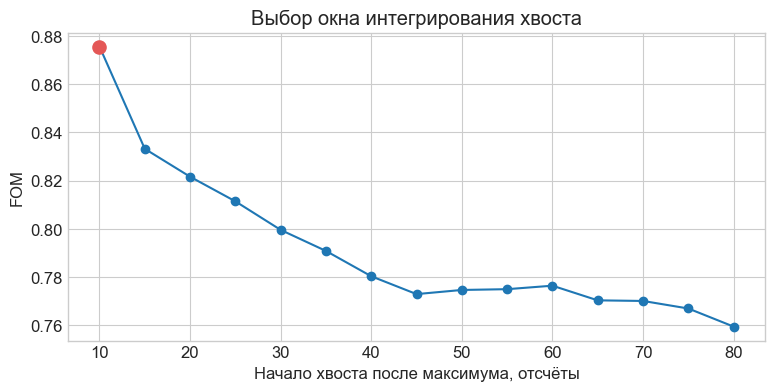

Лучшее начало хвоста: peak + 10 отсчётов


In [4]:
valid = amplitudes < SATURATION_AMPLITUDE
tail_offsets = np.arange(10, 81, 5)
fom_rows = []

for offset in tail_offsets:
    trial = np.array([integrate_pulse(pulse, peak, offset) for pulse, peak in zip(pulses, peak_bins)])
    trial_psd = trial[:, 2] / np.maximum(trial[:, 0], 1e-12)
    model = GaussianMixture(n_components=2, n_init=20, random_state=RANDOM_STATE).fit(trial_psd[valid, None])
    order = np.argsort(model.means_.ravel())
    means = model.means_.ravel()[order]
    stds = np.sqrt(model.covariances_.ravel())[order]
    fom = (means[1] - means[0]) / (2.355 * (stds[0] + stds[1]))
    fom_rows.append({"Начало хвоста": offset, "FOM": fom})

fom_table = pd.DataFrame(fom_rows)
best_offset = int(fom_table.loc[fom_table["FOM"].idxmax(), "Начало хвоста"])
display(fom_table.round(3))

plt.figure(figsize=(9, 4))
plt.plot(fom_table["Начало хвоста"], fom_table["FOM"], marker="o")
plt.scatter([best_offset], [fom_table["FOM"].max()], color="#e45756", s=90, zorder=3)
plt.xlabel("Начало хвоста после максимума, отсчёты")
plt.ylabel("FOM")
plt.title("Выбор окна интегрирования хвоста")
plt.show()

print(f"Лучшее начало хвоста: peak + {best_offset} отсчётов")

**Вывод по окну интегрирования.** Максимальный FOM получается при начале хвоста через 10 отсчётов после максимума. При увеличении смещения разделение постепенно ухудшается, поскольку часть различающего медленного компонента перестаёт входить в интеграл хвоста.

## 4. Разделение распределения PSD на два класса

События с амплитудой выше 14000 исключаются: их импульсы доходят почти до нулевого кода АЦП и насыщаются, поэтому отношение площадей искажается. Для оставшихся событий распределение PSD аппроксимируется смесью двух нормальных распределений.

In [5]:
valid = (amplitudes < SATURATION_AMPLITUDE) & np.isfinite(psd)
model = GaussianMixture(n_components=2, n_init=30, random_state=RANDOM_STATE).fit(psd[valid, None])

component_order = np.argsort(model.means_.ravel())
component_to_class = {component_order[0]: 0, component_order[1]: 1}
raw_labels = model.predict(psd[valid, None])
valid_labels = np.array([component_to_class[label] for label in raw_labels])

means = model.means_.ravel()[component_order]
stds = np.sqrt(model.covariances_.ravel())[component_order]
weights = model.weights_[component_order]
fom = (means[1] - means[0]) / (2.355 * (stds[0] + stds[1]))

# Находим точку пересечения взвешенных плотностей двух компонентов.
grid = np.linspace(psd[valid].min(), psd[valid].max(), 10000)
weighted_density = np.exp(model._estimate_weighted_log_prob(grid[:, None]))
difference = weighted_density[:, component_order[0]] - weighted_density[:, component_order[1]]
crossings = np.flatnonzero(np.diff(np.sign(difference)) != 0)
between = [i for i in crossings if means[0] < grid[i] < means[1]]
threshold = float(grid[between[0]])

class_id = np.full(len(waveforms), -1, dtype=int)
class_id[np.flatnonzero(valid)] = valid_labels
class_names = {
    -1: "Исключён: насыщение",
    0: "Быстрый класс (gamma/electron-like)",
    1: "Медленный класс (neutron/proton-like)",
}
signal_class = np.array([class_names[value] for value in class_id])

fit_summary = pd.DataFrame({
    "Класс": [class_names[0], class_names[1]],
    "Центр PSD": means,
    "Стандартное отклонение": stds,
    "Доля смеси": weights,
    "Количество": [(class_id == 0).sum(), (class_id == 1).sum()],
})
display(fit_summary.round(4))
print(f"Граница PSD: {threshold:.4f}")
print(f"FOM: {fom:.3f}")
print(f"Исключено насыщенных событий: {(~valid).sum()}")

,Класс,Центр PSD,Стандартное отклонение,Доля смеси,Количество
0,Быстрый класс (gamma/electron-like),0.1529,0.0415,0.444,863
1,Медленный класс (neutron/proton-like),0.3579,0.0579,0.556,1063


Граница PSD: 0.2397
FOM: 0.876
Исключено насыщенных событий: 74


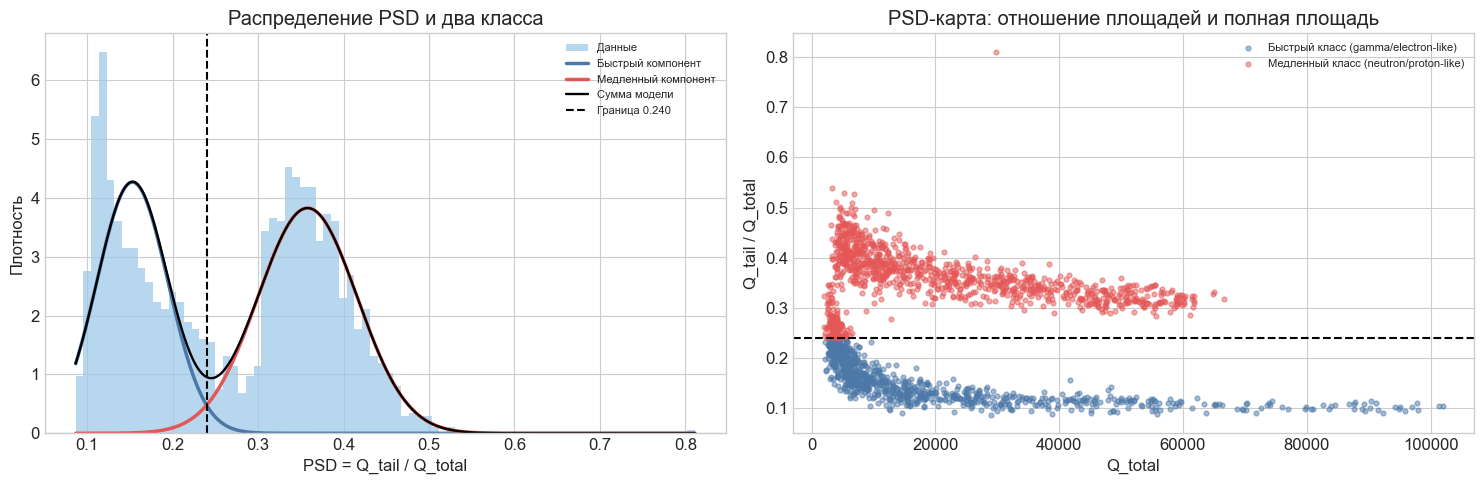

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.linspace(psd[valid].min(), psd[valid].max(), 700)
density = np.exp(model._estimate_weighted_log_prob(x[:, None]))
axes[0].hist(psd[valid], bins=80, density=True, color="#9ecae9", alpha=0.75, label="Данные")
axes[0].plot(x, density[:, component_order[0]], color="#4c78a8", lw=2.5, label="Быстрый компонент")
axes[0].plot(x, density[:, component_order[1]], color="#e45756", lw=2.5, label="Медленный компонент")
axes[0].plot(x, density.sum(axis=1), color="black", lw=1.7, label="Сумма модели")
axes[0].axvline(threshold, color="black", ls="--", label=f"Граница {threshold:.3f}")
axes[0].set_title("Распределение PSD и два класса")
axes[0].set_xlabel("PSD = Q_tail / Q_total")
axes[0].set_ylabel("Плотность")
axes[0].legend(fontsize=8)

colors = {0: "#4c78a8", 1: "#e45756"}
for cls in [0, 1]:
    mask = class_id == cls
    axes[1].scatter(q_total[mask], psd[mask], s=12, alpha=0.5, color=colors[cls], label=class_names[cls])
axes[1].axhline(threshold, color="black", ls="--", lw=1.5)
axes[1].set_title("PSD-карта: отношение площадей и полная площадь")
axes[1].set_xlabel("Q_total")
axes[1].set_ylabel("Q_tail / Q_total")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Сравнение форм двух классов

Чтобы сравнить именно форму, а не абсолютную высоту, каждый импульс делится на свою амплитуду. На графике показаны отдельные сигналы и средняя форма каждого класса. Заштрихованная область соответствует одному стандартному отклонению.

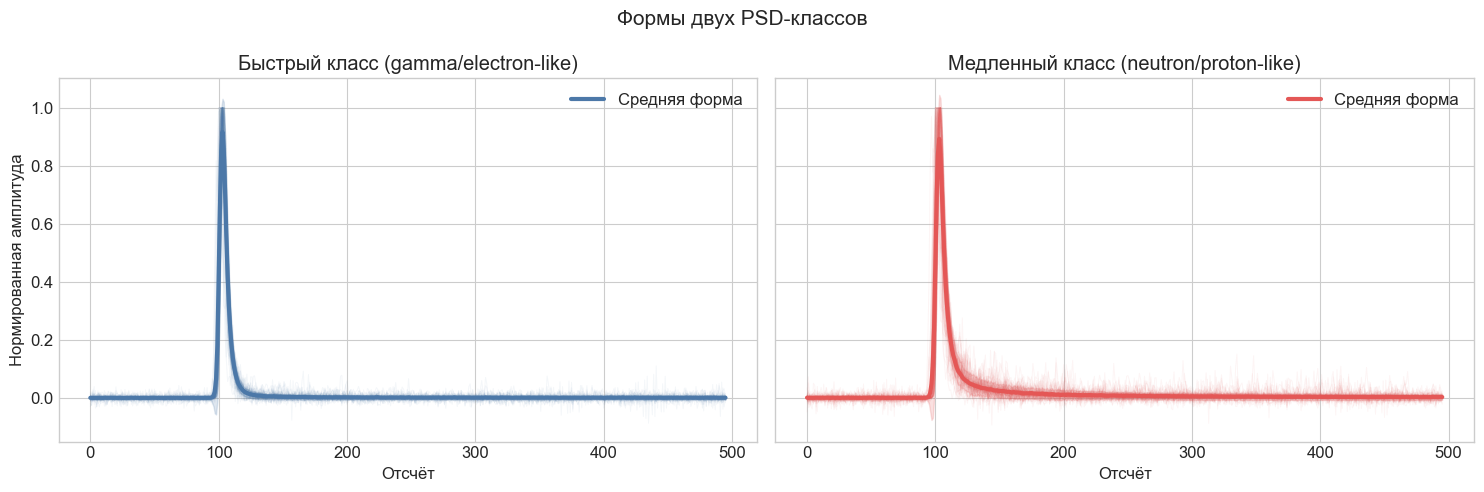

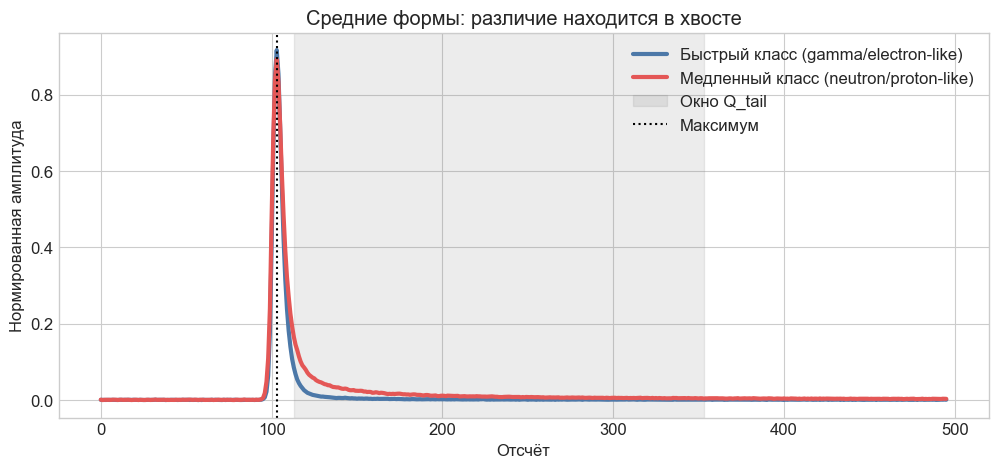

In [7]:
normalized_pulses = pulses / amplitudes[:, None]
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
rng = np.random.default_rng(RANDOM_STATE)

for ax, cls in zip(axes, [0, 1]):
    indices = np.flatnonzero(class_id == cls)
    shown = rng.choice(indices, size=min(70, len(indices)), replace=False)
    for idx in shown:
        ax.plot(normalized_pulses[idx], color=colors[cls], alpha=0.06, lw=0.7)
    mean_shape = normalized_pulses[indices].mean(axis=0)
    std_shape = normalized_pulses[indices].std(axis=0)
    time = np.arange(len(mean_shape))
    ax.plot(time, mean_shape, color=colors[cls], lw=3, label="Средняя форма")
    ax.fill_between(time, mean_shape - std_shape, mean_shape + std_shape, color=colors[cls], alpha=0.18)
    ax.set_title(class_names[cls])
    ax.set_xlabel("Отсчёт")
    ax.legend()

axes[0].set_ylabel("Нормированная амплитуда")
fig.suptitle("Формы двух PSD-классов", fontsize=15)
plt.tight_layout()
plt.show()

# Показываем две средние формы вместе и выделяем окно хвоста.
plt.figure(figsize=(12, 5))
for cls in [0, 1]:
    indices = np.flatnonzero(class_id == cls)
    plt.plot(normalized_pulses[indices].mean(axis=0), lw=3, color=colors[cls], label=class_names[cls])
median_peak = int(np.median(peak_bins[valid]))
plt.axvspan(median_peak + TAIL_START_OFFSET, min(waveforms.shape[1] - 1, median_peak + TOTAL_END_OFFSET),
            color="grey", alpha=0.15, label="Окно Q_tail")
plt.axvline(median_peak, color="black", ls=":", label="Максимум")
plt.xlabel("Отсчёт")
plt.ylabel("Нормированная амплитуда")
plt.title("Средние формы: различие находится в хвосте")
plt.legend()
plt.show()

### Вывод по форме

Оба класса имеют близкое положение максимума и сходный быстрый фронт. Главное различие проявляется после вершины:

- у быстрого класса хвост уменьшается быстрее, поэтому `Q_tail / Q_total` мало;
- у медленного класса после максимума остаётся заметно больше площади, поэтому PSD выше.

Именно это различие и создаёт два пика на гистограмме PSD и две области на двумерной PSD-карте.

## 6. Сохранение классификации

В итоговой таблице сохраняются интегралы, PSD, метка класса и признак исключения из-за насыщения.

In [8]:
classification = pd.DataFrame({
    "original_index": np.arange(len(waveforms)),
    "timetag": metadata["TIMETAG"].to_numpy(),
    "amplitude": amplitudes,
    "peak_bin": peak_bins,
    "q_total": q_total,
    "q_short": q_short,
    "q_tail": q_tail,
    "psd_tail_to_total": psd,
    "class_id": class_id,
    "signal_class": signal_class,
    "is_saturated": amplitudes >= SATURATION_AMPLITUDE,
})

class_summary = classification.groupby("signal_class", sort=False).agg(
    count=("original_index", "size"),
    median_amplitude=("amplitude", "median"),
    median_q_total=("q_total", "median"),
    median_psd=("psd_tail_to_total", "median"),
).reset_index()

classification.to_csv(OUTPUT_DIR / "psd_classification.csv", index=False)
class_summary.to_csv(OUTPUT_DIR / "psd_summary.csv", index=False)

display(class_summary.round(4))
print("Сохранено:")
print(" - signal_analysis/psd_classification.csv")
print(" - signal_analysis/psd_summary.csv")

,signal_class,count,median_amplitude,median_q_total,median_psd
0,Медленный класс (neutron/proton-like),1063,1196.0,14636.0,0.3562
1,Быстрый класс (gamma/electron-like),863,1459.0,11147.5,0.1452
2,Исключён: насыщение,74,15380.0,195134.0,0.1760


Сохранено:
 - signal_analysis/psd_classification.csv
 - signal_analysis/psd_summary.csv


## Итоговые выводы

1. Отношение площадей определено как `PSD = Q_tail / Q_total`. Это то же самое, что `1 − Q_short / Q_total`.
2. Оптимальное начало хвоста — через 10 отсчётов после максимума. Для этого окна FOM равен примерно 0,876.
3. Распределение PSD разделяется на два компонента с центрами около 0,153 и 0,358. Граница между ними находится около 0,240.
4. Быстрый класс содержит 863 события. Его медианное PSD равно примерно 0,145: после вершины остаётся сравнительно мало площади.
5. Медленный класс содержит 1063 события. Его медианное PSD равно примерно 0,356: хвост содержит существенно большую долю полной площади.
6. Ещё 74 события исключены из PSD-классификации из-за насыщения АЦП.
7. В типичной интерпретации органического сцинтиллятора быстрый класс соответствует гамма-событиям и электронным отдачам, а медленный — нейтронным событиям и протонным отдачам. Однако окончательно присвоить физические названия можно только по калибровочным данным или известным меткам источника.

Таким образом, два типа видны сразу тремя способами: как два пика распределения PSD, как две области на графике `PSD–Q_total` и как две различные средние формы хвоста.